In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, kstest, norm, f
from scipy.stats import gaussian_kde

### Carga de datos

In [2]:
df = pd.read_excel('datosejercicioevaluacionanchuras.xlsx')

In [3]:
df.head()

,Época histórica,Anchura del cráneo
0,1,133
1,1,131
2,1,131
3,1,132
4,1,134


In [4]:
df['Época histórica'].value_counts()

Época histórica
1    30
2    30
Name: count, dtype: int64

In [5]:
# Separación de sub-muestras
df_temprano = df.loc[df['Época histórica'] == 1][['Anchura del cráneo']]
df_tardio = df.loc[df['Época histórica'] == 2][['Anchura del cráneo']]

## Ejercicio 1

### Medidas de centralización y dispersión, asimetría y curtosis

In [6]:
def estadisticos_descriptivos(df):
    medidas_craneales = pd.DataFrame(df.describe())

    medidas = {
        'IQR': df.quantile(0.75) - df.quantile(0.25),
        'varianza': df.var(),
        'moda': df.mode().iloc[0],  # selecciona la primera moda si hay varias
        'rango': df.max() - df.min(),
        'coeficiente de variación de Pearson': df.std() / df.mean(),
        'coeficiente de asimetría de Fisher': skew(df),
        'coeficiente de curtosis': kurtosis(df),
    }

    medidas_craneales = pd.concat([medidas_craneales, pd.DataFrame(medidas, index=['Anchura del cráneo']).T])
    return medidas_craneales

medidas_temprano = estadisticos_descriptivos(df_temprano)
medidas_tardio = estadisticos_descriptivos(df_tardio)
df_combinado = pd.DataFrame({
    'Predinástico Temprano': medidas_temprano['Anchura del cráneo'],
    'Predinástico Tardío': medidas_tardio['Anchura del cráneo']
})
df_combinado.index = medidas_tardio.index
df_combinado

,Predinástico Temprano,Predinástico Tardío
count,30.000000,30.000000
mean,131.533333,132.466667
std,0.819307,1.008014
min,130.000000,131.000000
25%,131.000000,132.000000
50%,131.500000,133.000000
75%,132.000000,133.000000
max,134.000000,135.000000
IQR,1.000000,1.000000
varianza,0.671264,1.016092


### Histograma

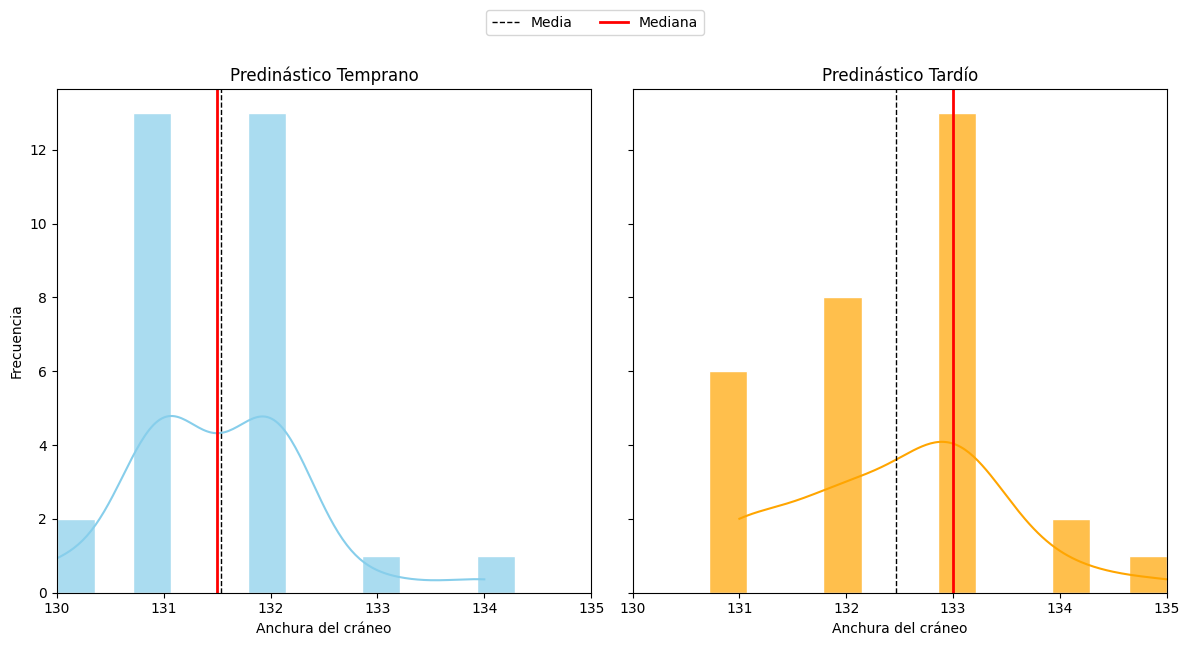

In [7]:
# Calcular los límites comunes para el eje X
x_min = min(df_temprano['Anchura del cráneo'].min(), df_tardio['Anchura del cráneo'].min())
x_max = max(df_temprano['Anchura del cráneo'].max(), df_tardio['Anchura del cráneo'].max())

# Calcular bins comunes para ambos histogramas
bins = np.linspace(x_min, x_max, 15) 

# Crear figura con dos subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)


# Gráfico predinástico temprano
sns.histplot(df_temprano['Anchura del cráneo'], bins=bins, ax=ax1, 
             color='skyblue', alpha=0.7, edgecolor='white', kde=True)
ax1.set_xlim(x_min, x_max)
mean_temprano = df_temprano['Anchura del cráneo'].mean()
median_temprano = df_temprano['Anchura del cráneo'].median()
# Añadimos líneas de la media y mediana
ax1.axvline(mean_temprano, ymin=0, ymax=1, 
            color='black', linestyle='--', linewidth=1)
ax1.axvline(median_temprano, ymin=0, ymax=1,
            color='red', linestyle='-', linewidth=2)
ax1.set_title('Predinástico Temprano')
ax1.set_xlabel('Anchura del cráneo')
ax1.set_ylabel('Frecuencia')


# Gráfico predinástico tardío
sns.histplot(df_tardio['Anchura del cráneo'], bins=bins, ax=ax2,
             color='orange', alpha=0.7, edgecolor='white', kde=True)
ax2.set_xlim(x_min, x_max)
mean_tardio = df_tardio['Anchura del cráneo'].mean()
median_tardio = df_tardio['Anchura del cráneo'].median()
# Añadimos líneas de la media y mediana
ax2.axvline(mean_tardio, ymin=0, ymax=1,
            color='black', linestyle='--', linewidth=1)
ax2.axvline(median_tardio, ymin=0, ymax=1,
            color='red', linestyle='-', linewidth=2)
ax2.set_title('Predinástico Tardío')
ax2.set_xlabel('Anchura del cráneo')
ax2.set_ylabel('')

# Leyenda
legend_elements = [
    Line2D([0], [0], color='black', lw=1, linestyle='--', label='Media'),
    Line2D([0], [0], color='red', lw=2, label='Mediana')
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),  # Crea espacio entre la gráfica y la leyenda
    ncol=2,
    frameon=True
)

# Ajustamos espacio entre gráficos
plt.tight_layout()
plt.show()

### Gráfico de densidad

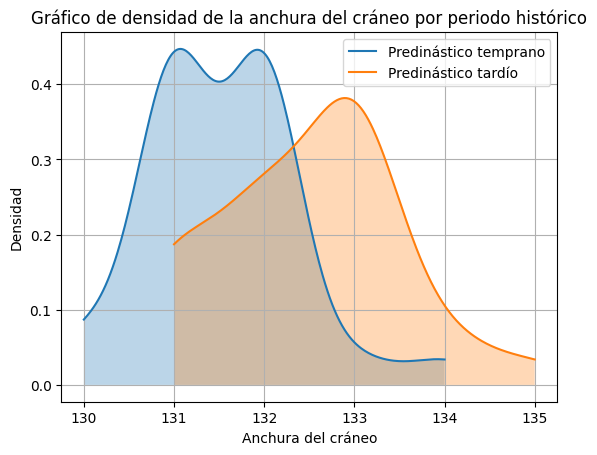

In [8]:
# Etiquetas descriptivas
etiquetas = {
    1: "Predinástico temprano",
    2: "Predinástico tardío"
}

plt.figure()

# Densidad por periodo
for epoca in sorted(df['Época histórica'].unique()):
    data = df[df['Época histórica'] == epoca]['Anchura del cráneo'].dropna()
    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 300)
    y = kde(x)
    plt.plot(x, y, label=etiquetas[epoca])
    plt.fill_between(x, y, alpha=0.3)

plt.xlabel('Anchura del cráneo')
plt.ylabel('Densidad')
plt.title('Gráfico de densidad de la anchura del cráneo por periodo histórico')
plt.legend()
plt.grid(True)
plt.show()

### Diagrama de caja y bigote (Boxplot)

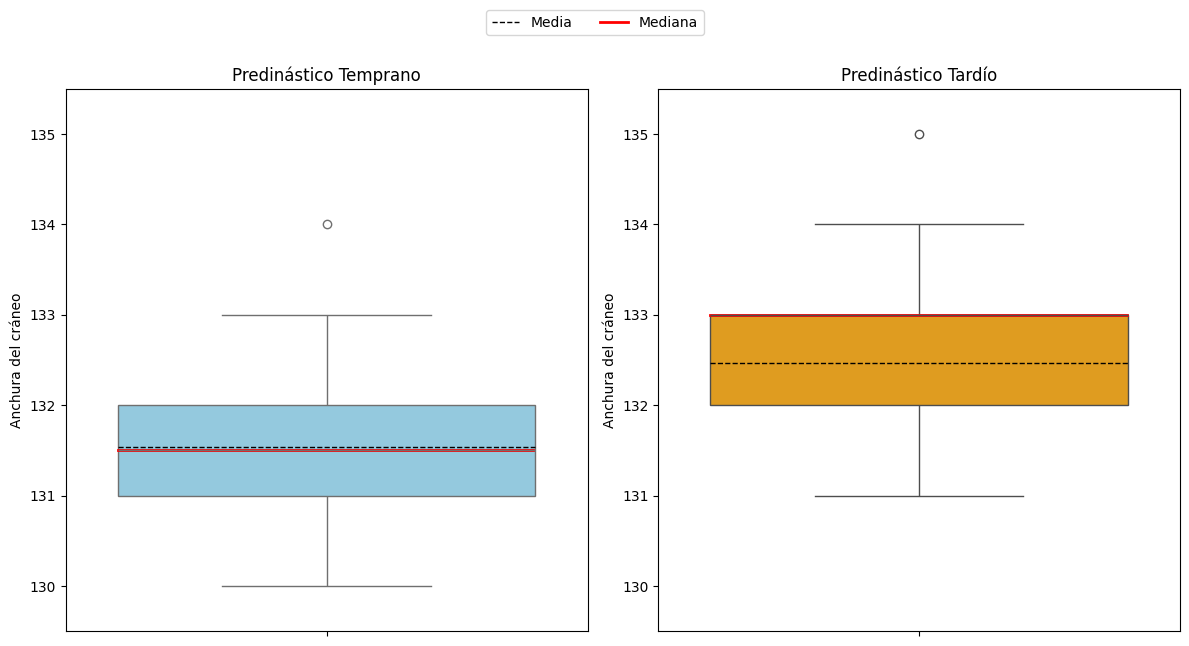

In [9]:
# Calcular los límites comunes para el eje Y
y_min = min(df_temprano['Anchura del cráneo'].min(), df_tardio['Anchura del cráneo'].min()) -0.5
y_max = max(df_temprano['Anchura del cráneo'].max(), df_tardio['Anchura del cráneo'].max()) +0.5

# Crear figura con dos subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))


# Gráfico predinástico temprano
sns.boxplot(y='Anchura del cráneo', data=df_temprano, ax=ax1, color='skyblue')
ax1.set_ylim(y_min, y_max)  # Establece límites Y
mean_temprano = df_temprano['Anchura del cráneo'].mean()
median_temprano = df_temprano['Anchura del cráneo'].median()
# Añadimos líneas de la media y mediana
ax1.axhline(mean_temprano, xmin=0.1, xmax=0.9, 
            color='black', linestyle='--', linewidth=1)
ax1.axhline(median_temprano, xmin=0.1, xmax=0.895, 
            color='red', linestyle='-', linewidth=2)
ax1.set_title('Predinástico Temprano')


# Gráfico predinástico tardío
sns.boxplot(y='Anchura del cráneo', data=df_tardio, ax=ax2, color='orange')
ax2.set_ylim(y_min, y_max)  # Establecer los MISMOS límites Y
mean_tardio = df_tardio['Anchura del cráneo'].mean()
median_tardio = df_tardio['Anchura del cráneo'].median()
# Añadimos líneas de la media y mediana
ax2.axhline(mean_tardio, xmin=0.1, xmax=0.9, 
            color='black', linestyle='--', linewidth=1)
ax2.axhline(median_tardio, xmin=0.1, xmax=0.899, 
            color='red', linestyle='-', linewidth=2)
ax2.set_title('Predinástico Tardío')


# Leyenda
legend_elements = [
    Line2D([0], [0], color='black', lw=1, linestyle='--', label='Media'),
    Line2D([0], [0], color='red', lw=2, label='Mediana')
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),  # Crea espacio entre la gráfica y la leyenda
    ncol=2,
    frameon=True
)

# Ajustamos el espacio entre gráficos
plt.tight_layout()
plt.show()

### Distribución normal (test de Kolmogorov-Smirnov).

In [10]:
def estandarizar_datos(df):
    return (df - df.mean()) / df.std()

def prueba_kolmogorov_smirnov(columna, datos):
    df = estandarizar_datos(datos)
    
    # Realizar el test KS contra una normal teórica con esos parámetros
    ks_stat, p_valor = kstest(
        df, 
        'norm', 
        args=(0, 1) 
    )
    
    print(f"Normalidad {columna}")
    print(f"KS Estadístico: {ks_stat:.4f}")
    print(f"p-valor: {p_valor:.4f}")
    if p_valor > 0.05:
        print('La muestra proviene de una distribución normal')
        print()
    else:
        print('La muestra no proviene de una distribución normal')
        print()

# Aplicar el test a ambas columnas
prueba_kolmogorov_smirnov('Predinástico Temprano', df_temprano['Anchura del cráneo'])
prueba_kolmogorov_smirnov('Predinástico Tardío', df_tardio['Anchura del cráneo'])

Normalidad Predinástico Temprano
KS Estadístico: 0.2425
p-valor: 0.0489
La muestra no proviene de una distribución normal

Normalidad Predinástico Tardío
KS Estadístico: 0.2350
p-valor: 0.0611
La muestra proviene de una distribución normal



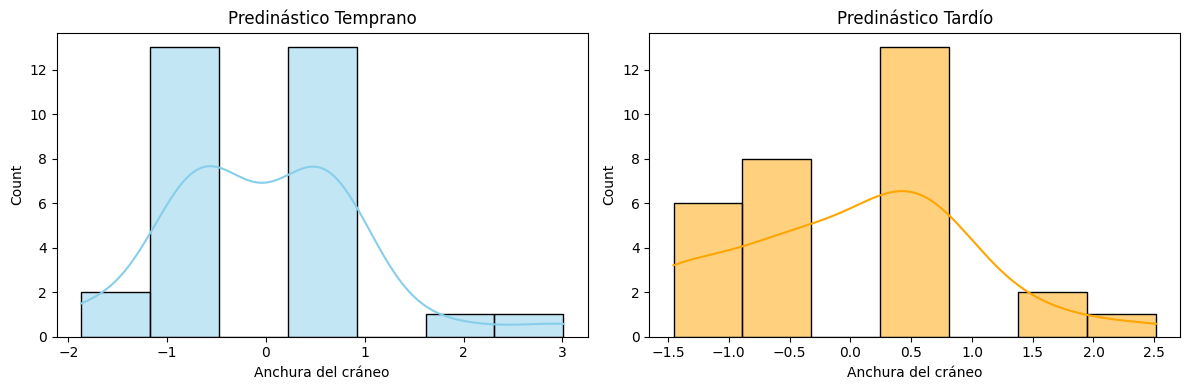

In [11]:
# Gráfico de las distribuciones normalizadas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramas
sns.histplot(estandarizar_datos(df_temprano['Anchura del cráneo']), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Predinástico Temprano')
sns.histplot(estandarizar_datos(df_tardio['Anchura del cráneo']), kde=True, ax=axes[1], color='orange')
axes[1].set_title('Predinástico Tardío')

plt.tight_layout()
plt.show()

## Ejercicio 2

### Intervalos de Confianza y Homocedasticidad

In [12]:
# Realizar prueba F para igualdad de varianzas
def prueba_f_fisher(muestra1, muestra2, confianza=0.90):
    var1 = np.var(muestra1, ddof=1)
    var2 = np.var(muestra2, ddof=1)
    
    # Estadístico F (>1)
    if var1 >= var2:
        F = var1 / var2
        grado_libertad_num = len(muestra1) - 1
        grado_libertad_den = len(muestra2) - 1
    else:
        F = var2 / var1
        grado_libertad_num = len(muestra2) - 1
        grado_libertad_den = len(muestra1) - 1
    
    # Valores críticos
    alpha = 1 - confianza
    f_critico_inf = stats.f.ppf(alpha/2, grado_libertad_num, grado_libertad_den)
    f_critico_sup = stats.f.ppf(1 - alpha/2, grado_libertad_num, grado_libertad_den)
    
    return F, f_critico_inf, f_critico_sup, grado_libertad_num, grado_libertad_den

# Prueba (90% de confianza)
F_obs, f_inf, f_sup, grado_libertad_num, grado_libertad_den = prueba_f_fisher(df_temprano['Anchura del cráneo'], df_tardio['Anchura del cráneo'], 0.90)

print(f"Estadístico F = {F_obs:.3f}")
print(f"Región de aceptación: [{f_inf:.3f}, {f_sup:.3f}]")

if f_inf < F_obs < f_sup:
    print("No rechazamos H0: Las muestras poseen varianzas poblacionales iguales.")
else:
    print("Rechazamos H0: Las muestras poseen varianzas poblacionales diferentes.")

Estadístico F = 1.514
Región de aceptación: [0.537, 1.861]
No rechazamos H0: Las muestras poseen varianzas poblacionales iguales.


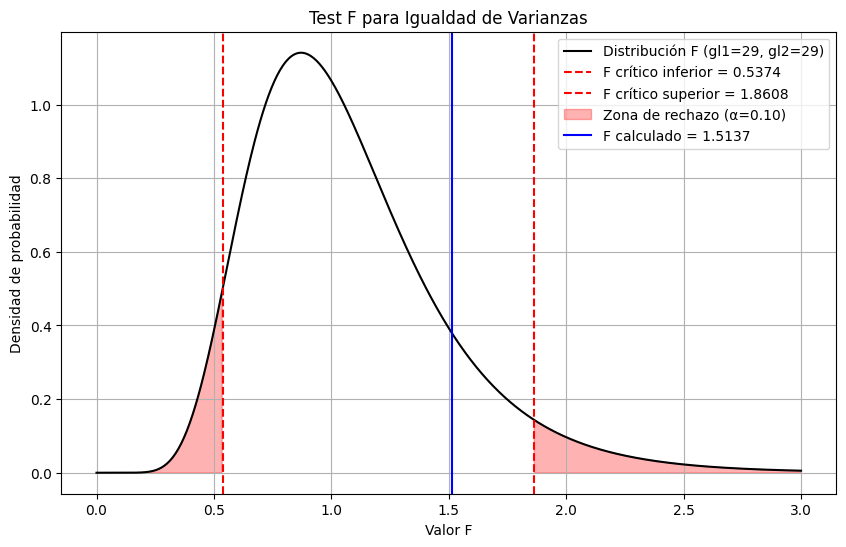

In [13]:
alpha = 0.10
F_critico_inferior = stats.f.ppf(alpha/2, grado_libertad_num, grado_libertad_den)  # ≈ 0.5374
F_critico_superior = stats.f.ppf(1 - alpha/2, grado_libertad_num, grado_libertad_den)  # ≈ 1.8608

# Crear distribución F
x = np.linspace(0, 3, 500)
y = stats.f.pdf(x, grado_libertad_num, grado_libertad_den)

# Gráfica
plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f'Distribución F (gl1={grado_libertad_num}, gl2={grado_libertad_den})', color='black')

# Líneas críticas y región de rechazo
plt.axvline(F_critico_inferior, color='red', linestyle='--', label=f'F crítico inferior = {F_critico_inferior:.4f}')
plt.axvline(F_critico_superior, color='red', linestyle='--', label=f'F crítico superior = {F_critico_superior:.4f}')

# Rellenar zona de rechazo (rojo)
plt.fill_between(x, y, where=(x <= F_critico_inferior) | (x >= F_critico_superior), color='red', alpha=0.3, label='Zona de rechazo (α=0.10)')

# Marcar el F calculado
plt.axvline(F_obs, color='blue', linestyle='-', label=f'F calculado = {F_obs:.4f}')

# Personalización
plt.title('Test F para Igualdad de Varianzas')
plt.xlabel('Valor F')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
def intervalos_confianza_medias(muestra1, muestra2, confianza=0.95):
    # Convertimos a arreglos de numpy y aplanamos
    m1 = np.asarray(muestra1).flatten()
    m2 = np.asarray(muestra2).flatten()
    
    n1, n2 = len(m1), len(m2)
    mean1, mean2 = np.mean(m1), np.mean(m2)
    var1, var2 = np.var(m1, ddof=1), np.var(m2, ddof=1)
    
    diff = mean1 - mean2
    

    # Asumimos varianzas iguales por el resultado del apartado previo
    # Grados de libertad: n1 + n2 - 2
    gl = n1 + n2 - 2
        
    # Varianza combinada (Pooled Variance)
    sp_squared = ((n1 - 1) * var1 + (n2 - 1) * var2) / gl
        
    # Error estándar (con varianza combinada)
    se = np.sqrt(sp_squared * (1/n1 + 1/n2))
    
    # Valor crítico t
    t_critico = stats.t.ppf((1 + confianza)/2, gl)
    
    # Margen de error e intervalo
    margen = t_critico * se
    return (diff - margen, diff + margen)

# Calcular para distintos niveles de confianza
niveles_confianza = [0.90, 0.95, 0.99]

print("Intervalos de confianza para la diferencia de medias (Predinástico Tardío - Predinástico Temprano):")
for confianza in niveles_confianza:
    ic_inf, ic_sup = intervalos_confianza_medias(df_tardio, df_temprano, confianza)
    print(f"{confianza*100:.0f}% de confianza:")
    print(f"Intervalo: [{ic_inf:.3f}, {ic_sup:.3f}] mm\n")

Intervalos de confianza para la diferencia de medias (Predinástico Tardío - Predinástico Temprano):
90% de confianza:
Intervalo: [0.537, 1.330] mm

95% de confianza:
Intervalo: [0.459, 1.408] mm

99% de confianza:
Intervalo: [0.302, 1.565] mm



### Test t

In [15]:
data_temprano = df_temprano['Anchura del cráneo'].dropna()
data_tardio = df_tardio['Anchura del cráneo'].dropna()

# Test t (equal_var=True asume varianzas iguales homoscedasticidad)
# Si el test F anterior salió significativo, cambiar a equal_var=False
t_stat, p_value = stats.ttest_ind(data_temprano, data_tardio, equal_var=True)

# Cálculo dinámico de grados de libertad para varianzas iguales
gl = len(data_temprano) + len(data_tardio) - 2

print(f"Estadístico t = {t_stat:.4f}")

# Valor crítico al 95% de confianza (bilateral -> alpha=0.05 -> colas 0.025)
alpha = 0.05
t_critico = stats.t.ppf(1 - alpha/2, df=gl) 
print(f"Valor crítico bilateral (95%): ±{t_critico:.4f}")

if abs(t_stat) > t_critico:
    print("Rechazamos H0: Existe una diferencia significativa entre las medias.")
else:
    print("No rechazamos H0: No hay evidencia suficiente de diferencia de medias.")

Estadístico t = -3.9354
Valor crítico bilateral (95%): ±2.0017
Rechazamos H0: Existe una diferencia significativa entre las medias.


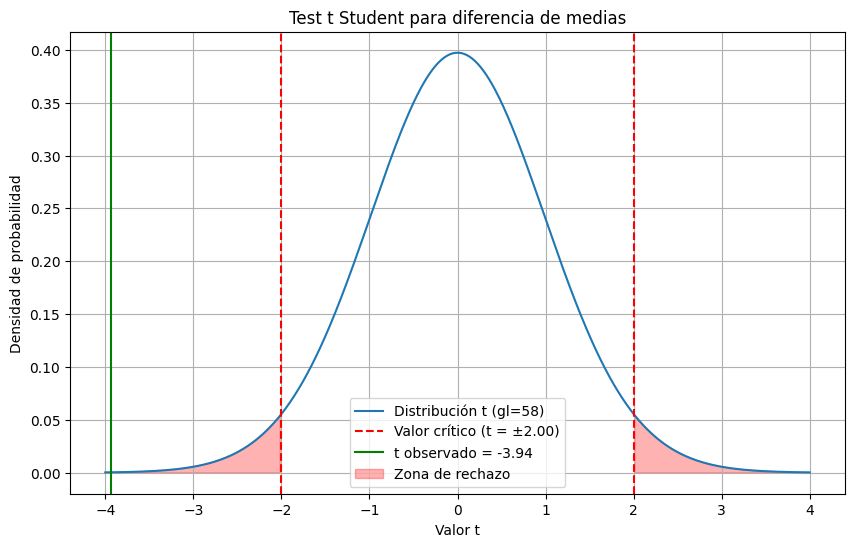

In [16]:
# Gráfico
x = np.linspace(-4, 4, 500)
# Usamos los grados de libertad calculados dinámicamente en la celda anterior (df_t)
y = stats.t.pdf(x, df=gl) 

plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f'Distribución t (gl={gl})')

# Zonas de rechazo
plt.axvline(t_critico, color='red', linestyle='--', label=f'Valor crítico (t = ±{t_critico:.2f})')
plt.axvline(-t_critico, color='red', linestyle='--')

# t observado
plt.axvline(t_stat, color='green', linestyle='-', label=f't observado = {t_stat:.2f}')

# Rellenar zonas de rechazo
plt.fill_between(x, y, where=(x >= t_critico) | (x <= -t_critico), color='red', alpha=0.3, label='Zona de rechazo')

plt.title('Test t Student para diferencia de medias')
plt.xlabel('Valor t')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid(True)
plt.show()